<a href="https://colab.research.google.com/github/JBadawood/Mathematical_Optimization/blob/main/Queueing-Systems/Generating_Random_Variates_(Service_Times).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Exponential (mean = 10.00) ---
Sample mean: 9.57, Sample std: 9.30

--- Normal (mean = 10.00, std = 1.50) ---
Sample mean: 9.97, Sample std: 1.52

--- Uniform (low = 8.00, high = 12.00) ---
Sample mean: 10.03, Sample std: 1.14

--- Triangular (min = 7.00, mode = 10.00, max = 15.00) ---
Sample mean: 10.74, Sample std: 1.64

--- Lognormal (target mean approx = 10.00, using cv = 0.3) ---
Sample mean: 10.04, Sample std: 3.00

--- Weibull (target mean approx = 10.00, shape k = 2.0) ---
Sample mean: 10.24, Sample std: 5.34

--- Gamma (target mean = 10.00, target std = 2.50) ---
Calculated shape k: 16.00, Calculated scale theta: 0.62
Sample mean: 9.89, Sample std: 2.47


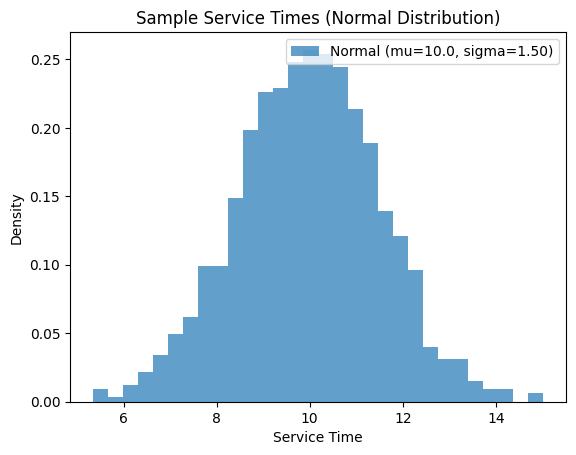

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Let's assume your "deterministic" processing time is T_d
T_d = 10.0  # minutes, seconds, or any unit

# --- 1. Exponential Distribution ---
# Assuming T_d is the mean (beta) of the exponential distribution
beta_exp = T_d
service_times_exp = np.random.exponential(scale=beta_exp, size=1000)

print(f"\n--- Exponential (mean = {beta_exp:.2f}) ---")
print(f"Sample mean: {np.mean(service_times_exp):.2f}, Sample std: {np.std(service_times_exp):.2f}")

# --- 2. Normal Distribution ---
# Assuming T_d is the mean (mu). We need to define a standard deviation (sigma).
# Let's say sigma is 15% of the mean.
mu_norm = T_d
sigma_norm = 0.15 * T_d
service_times_norm = np.random.normal(loc=mu_norm, scale=sigma_norm, size=1000)
# Ensure non-negativity if critical (can use truncated normal from scipy.stats or regenerate)
service_times_norm = np.maximum(0, service_times_norm) # Simple truncation at 0

print(f"\n--- Normal (mean = {mu_norm:.2f}, std = {sigma_norm:.2f}) ---")
print(f"Sample mean: {np.mean(service_times_norm):.2f}, Sample std: {np.std(service_times_norm):.2f}")

# --- 3. Uniform Distribution ---
# Assuming T_d is the midpoint, and variation is +/- 20% of T_d
variation_uniform = 0.20 * T_d
low_uniform = T_d - variation_uniform
high_uniform = T_d + variation_uniform
service_times_uniform = np.random.uniform(low=low_uniform, high=high_uniform, size=1000)

print(f"\n--- Uniform (low = {low_uniform:.2f}, high = {high_uniform:.2f}) ---")
print(f"Sample mean: {np.mean(service_times_uniform):.2f}, Sample std: {np.std(service_times_uniform):.2f}")

# --- 4. Triangular Distribution ---
# Assuming T_d is the mode (most likely value).
# Let min be T_d - 30% and max be T_d + 50% (can be asymmetric)
min_tri = T_d * 0.7
mode_tri = T_d
max_tri = T_d * 1.5
# numpy.random.triangular takes left, mode, right. Mode is relative to left if left is not 0.
# It's often easier to use scipy.stats.triang for standard (a, c, b) parameters
# where c is the mode in absolute terms, and loc=a, scale=b-a
# The `c` parameter in scipy.stats.triang is (mode-a)/(b-a)
c_param_scipy = (mode_tri - min_tri) / (max_tri - min_tri)
service_times_tri = stats.triang.rvs(c=c_param_scipy, loc=min_tri, scale=(max_tri - min_tri), size=1000)

print(f"\n--- Triangular (min = {min_tri:.2f}, mode = {mode_tri:.2f}, max = {max_tri:.2f}) ---")
print(f"Sample mean: {np.mean(service_times_tri):.2f}, Sample std: {np.std(service_times_tri):.2f}")

# --- 5. Lognormal Distribution ---
# Assuming T_d is the desired MEAN of the lognormal.
# Let's assume a coefficient of variation (cv = std_dev / mean) of 0.3
mu_ln_target = T_d
cv_ln = 0.3

# Calculate parameters for the underlying normal distribution
sigma_underlying_norm = np.sqrt(np.log(cv_ln**2 + 1))
mu_underlying_norm = np.log(mu_ln_target) - 0.5 * (sigma_underlying_norm**2)

service_times_lognorm = np.random.lognormal(mean=mu_underlying_norm, sigma=sigma_underlying_norm, size=1000)

print(f"\n--- Lognormal (target mean approx = {mu_ln_target:.2f}, using cv = {cv_ln}) ---")
print(f"Sample mean: {np.mean(service_times_lognorm):.2f}, Sample std: {np.std(service_times_lognorm):.2f}")

# --- 6. Weibull Distribution (using scipy.stats for easier parameterization with shape/scale) ---
# Assuming T_d is the MEAN. We need to choose a shape parameter k.
# Let shape k = 2 (Rayleigh-like, increasing failure/completion rate)
import math
shape_k_weibull = 2.0
# Mean of Weibull is scale * Gamma(1 + 1/shape_k)
# So, scale = T_d / Gamma(1 + 1/shape_k)
scale_lambda_weibull = T_d / math.gamma(1 + 1/shape_k_weibull)

# scipy.stats.weibull_min uses c for shape and scale for scale.
service_times_weibull = stats.weibull_min.rvs(c=shape_k_weibull, scale=scale_lambda_weibull, size=1000)

print(f"\n--- Weibull (target mean approx = {T_d:.2f}, shape k = {shape_k_weibull}) ---")
print(f"Sample mean: {np.mean(service_times_weibull):.2f}, Sample std: {np.std(service_times_weibull):.2f}")

# --- 7. Gamma Distribution ---
# We want mean = T_d. We need to define a desired standard deviation, sigma_gamma_desired.
# Let's say sigma_gamma_desired is 25% of T_d.
sigma_gamma_desired = 0.25 * T_d
if T_d > 0 and sigma_gamma_desired > 0:
    variance_gamma_desired = sigma_gamma_desired**2
    # shape_k_gamma = T_d^2 / variance_gamma_desired
    shape_k_gamma = (T_d**2) / variance_gamma_desired
    # scale_theta_gamma = variance_gamma_desired / T_d
    scale_theta_gamma = variance_gamma_desired / T_d

    service_times_gamma = np.random.gamma(shape=shape_k_gamma, scale=scale_theta_gamma, size=1000)
    print(f"\n--- Gamma (target mean = {T_d:.2f}, target std = {sigma_gamma_desired:.2f}) ---")
    print(f"Calculated shape k: {shape_k_gamma:.2f}, Calculated scale theta: {scale_theta_gamma:.2f}")
    print(f"Sample mean: {np.mean(service_times_gamma):.2f}, Sample std: {np.std(service_times_gamma):.2f}")
else:
    print(f"\n--- Gamma: Invalid T_d or sigma_gamma_desired for parameter calculation. ---")
    print(f"T_d: {T_d}, sigma_gamma_desired: {sigma_gamma_desired}")


# --- Visualization (Optional: Plot one of the distributions) ---
plt.hist(service_times_norm, bins=30, density=True, alpha=0.7, label=f'Normal (mu={mu_norm}, sigma={sigma_norm:.2f})')
plt.title('Sample Service Times (Normal Distribution)')
plt.xlabel('Service Time')
plt.ylabel('Density')
plt.legend()
plt.show()

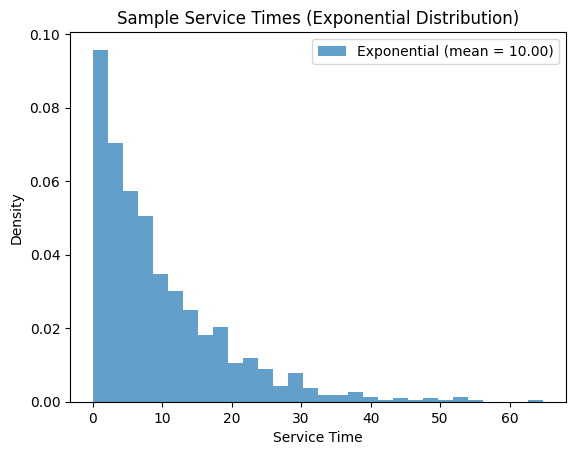

In [ ]:
plt.hist(service_times_exp, bins=30, density=True, alpha=0.7, label=f'Exponential (mean = {beta_exp:.2f})')
plt.title('Sample Service Times (Exponential Distribution)')
plt.xlabel('Service Time')
plt.ylabel('Density')
plt.legend()
plt.show()

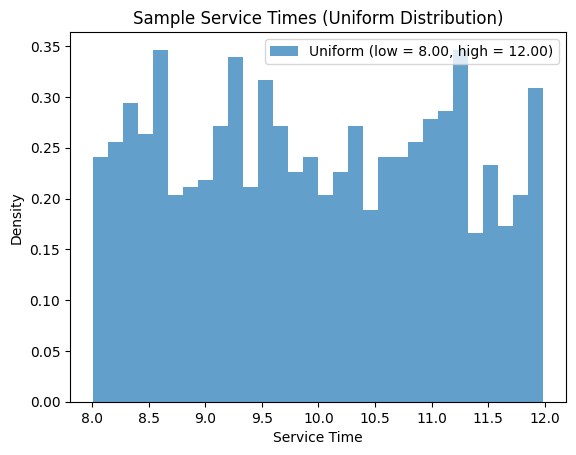

In [ ]:
plt.hist(service_times_uniform, bins=30, density=True, alpha=0.7, label=f'Uniform (low = {low_uniform:.2f}, high = {high_uniform:.2f})')
plt.title('Sample Service Times (Uniform Distribution)')
plt.xlabel('Service Time')
plt.ylabel('Density')
plt.legend()
plt.show()

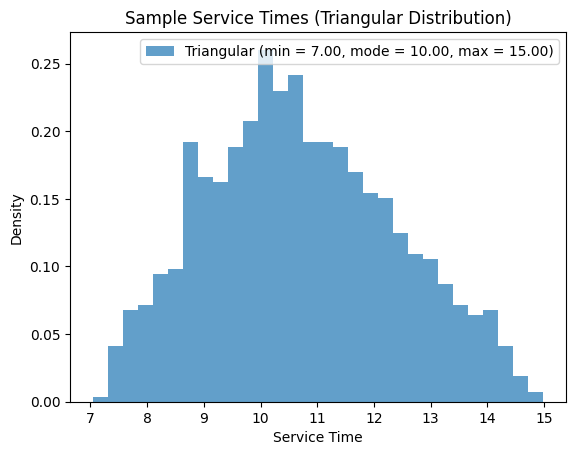

In [ ]:
plt.hist(service_times_tri, bins=30, density=True, alpha=0.7, label=f'Triangular (min = {min_tri:.2f}, mode = {mode_tri:.2f}, max = {max_tri:.2f})')
plt.title('Sample Service Times (Triangular Distribution)')
plt.xlabel('Service Time')
plt.ylabel('Density')
plt.legend()
plt.show()

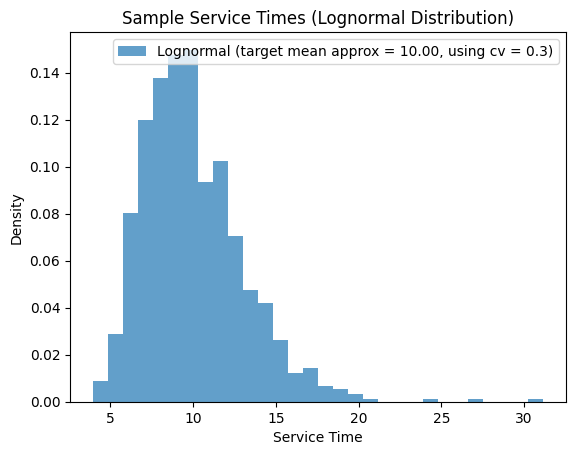

In [ ]:
plt.hist(service_times_lognorm, bins=30, density=True, alpha=0.7, label=f'Lognormal (target mean approx = {mu_ln_target:.2f}, using cv = {cv_ln})')
plt.title('Sample Service Times (Lognormal Distribution)')
plt.xlabel('Service Time')
plt.ylabel('Density')
plt.legend()
plt.show()

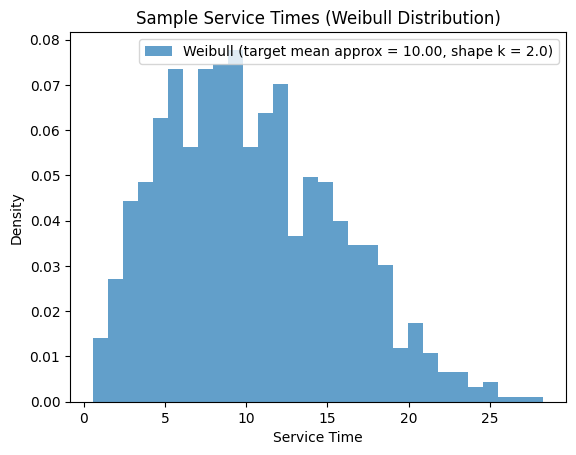

In [ ]:
plt.hist(service_times_weibull, bins=30, density=True, alpha=0.7, label=f'Weibull (target mean approx = {T_d:.2f}, shape k = {shape_k_weibull})')
plt.title('Sample Service Times (Weibull Distribution)')
plt.xlabel('Service Time')
plt.ylabel('Density')
plt.legend()
plt.show()

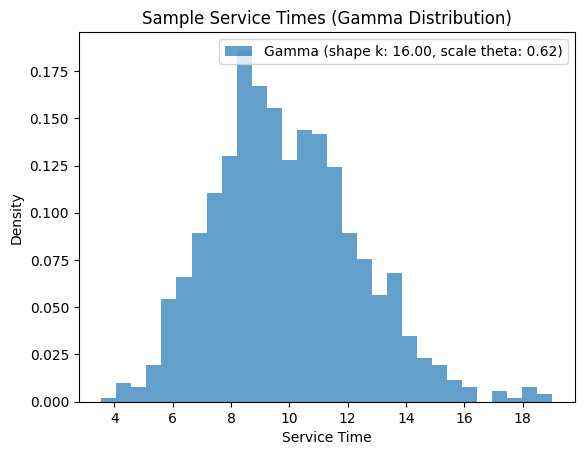

In [ ]:
plt.hist(service_times_gamma, bins=30, density=True, alpha=0.7, label=f'Gamma (shape k: {shape_k_gamma:.2f}, scale theta: {scale_theta_gamma:.2f})')
plt.title('Sample Service Times (Gamma Distribution)')
plt.xlabel('Service Time')
plt.ylabel('Density')
plt.legend()
plt.show()